In [53]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# تحميل ملفات NLTK الضرورية

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
df = pd.read_csv('IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [55]:
# عرض البيانات (نأخذ عينة 5000 مراجعة لسرعة التدريب في المتصفح)

df = df.sample(20000, random_state=42)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("شكل البيانات:", df.shape)
print(df.head())


شكل البيانات: (20000, 2)
                                                  review  sentiment
33553  I really liked this Summerslam due to the look...          1
9427   Not many television shows appeal to quite as m...          1
199    The film quickly gets to a major chase scene w...          0
12447  Jane Austen would definitely approve of this o...          1
39489  Expectations were somewhat high for me when I ...          0


In [56]:
df.describe()

,sentiment
count,20000.000000
mean,0.500550
std,0.500012
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [57]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [58]:
df

,review,sentiment
33553,I really liked this Summerslam due to the look...,1
9427,Not many television shows appeal to quite as m...,1
199,The film quickly gets to a major chase scene w...,0
12447,Jane Austen would definitely approve of this o...,1
39489,Expectations were somewhat high for me when I ...,0
...,...,...
14324,A touching movie about a talented woman who st...,1
43453,I just came from seeing this movie and decided...,0
29499,Dolemite is one of the best movies featuring a...,1
42681,"In the future, a disparate group of people asl...",1


In [59]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [60]:
def remove_noise(text):
    text = re.sub(r'@\w+', '', text)                   # remove mentions (@user)
    text = re.sub(r'#\w+', '', text)                   # remove hashtags (#word)
    text = re.sub(r'http\S+|www\S+', '', text)         # remove links
    text = re.sub(r'\d+', '', text)                    # remove numbers
    text = re.sub(r'[^\x00-\x7F\u0600-\u06FF]', '', text)  # remove emojis & special chars
    return text

def to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def tokenize_text(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 1]

def apply_stemming(tokens):
    return [stemmer.stem(t) for t in tokens]

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]



In [61]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = remove_noise(text)
    text = to_lowercase(text)
    text = remove_punctuation(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)
    tokens = apply_stemming(tokens)
    tokens = apply_lemmatization(tokens)

    return " ".join(tokens)

In [62]:
df['clean_review'] = df['review'].apply(preprocess_text)

In [63]:
print("\n Sample before and after preprocessing:\n")
for i in range(5):
    print("Original:", df.iloc[i]['review'])
    print("-" * 100)
    print("Cleaned :", df.iloc[i]['clean_review'])
    print("-" * 100)



 Sample before and after preprocessing:

Original: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bige

In [64]:
X = df['clean_review']
y = df['sentiment']

# تقسيم البيانات إلى تدريب واختبار (80% تدريب، 20% اختبار)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# الطريقة الأولى: Bag of Words (BoW)
'''
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train_raw)
X_test_bow = bow_vectorizer.transform(X_test_raw)
'''

# الطريقة الثانية: TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

# شرح أكاديمي: 
# BoW: يعتمد فقط على التكرار.
# TF-IDF: يعطي وزناً أكبر للكلمات المميزة للمراجعة ويقلل من شأن الكلمات الشائعة عبر كل المراجعات.

In [65]:
# 1. Linear Regression
# ملاحظة: سنستخدم threshold (عتبة) 0.5 لأن Linear Regression يتنبأ بقيم مستمرة
'''
lin_reg = LinearRegression()
lin_reg.fit(X_train_tfidf, y_train)
lin_preds = lin_reg.predict(X_test_tfidf)
lin_preds_class = [1 if p >= 0.5 else 0 for p in lin_preds]
'''

# 2. Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)
log_preds = log_reg.predict(X_test_tfidf)

# لماذا Logistic Regression أفضل؟
# لأنه يستخدم دالة Sigmoid التي تخرج احتمالات بين 0 و 1، وهي مصممة خصيصاً للتصنيف الثنائي.

--- تقييم نموذج: Logistic Regression ---
Accuracy:  0.8828
Precision: 0.8663
Recall:    0.9057
F1-Score:  0.8856
------------------------------


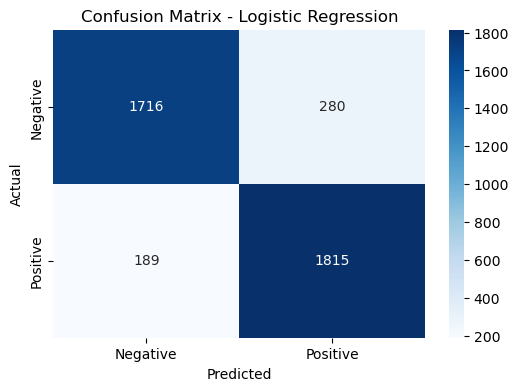

In [66]:
def print_evaluation(y_true, y_pred, model_name):
    print(f"--- تقييم نموذج: {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("-" * 30)

#print_evaluation(y_test, lin_preds_class, "Linear Regression")
print_evaluation(y_test, log_preds, "Logistic Regression")

# عرض مصفوفة الارتباك (Confusion Matrix) للنموذج الأفضل
cm = confusion_matrix(y_test, log_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()